# Model Lab

Visual verification of each sub-model in the analytics pipeline.
Each section answers one question with one chart. `model.py` has the math — this notebook just plots it.

**Pipeline:** Raw intake → EWMA smoothing → WLS weight slope → Forbes ρ → Confidence blending → Maintenance → Budget

In [70]:
from datetime import date, timedelta

import matplotlib.pyplot as plt
import numpy as np

from model import *
from constants import *

REF = date(2026, 2, 21)

## 1. EWMA — How does the smoother handle real-world intake patterns?

Three scenarios: (a) a binge spike, (b) a 5-day tracking gap, (c) different α values on the same noisy data.

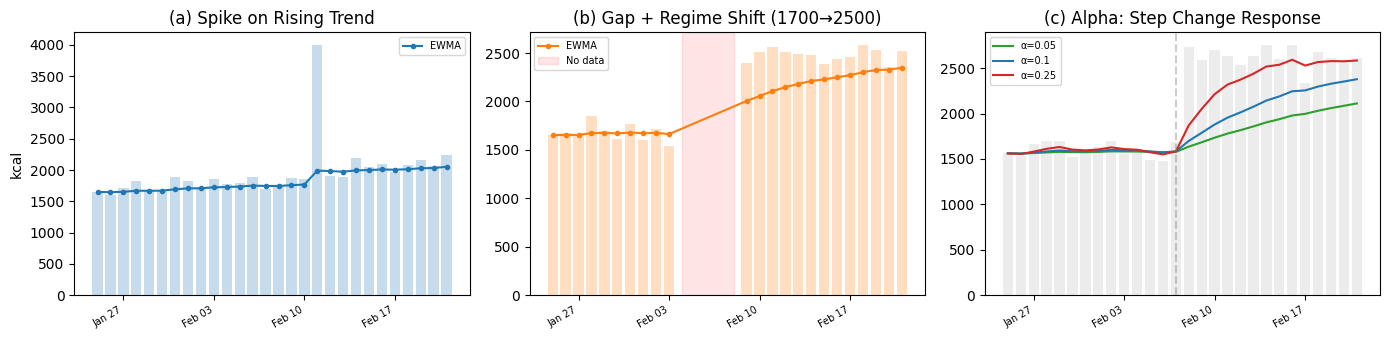

In [71]:
np.random.seed(42)
import matplotlib.dates as mdates


def rolling_ewma(series, alpha=MAINTENANCE_ALPHA):
    """EWMA at each date in order."""
    dates = sorted(series)
    vals = []
    for dt in dates:
        sub = {d: v for d, v in series.items() if d <= dt}
        vals.append(ewma(sub, alpha=alpha, ref_date=dt) or 0)
    return dates, vals


def fmt_axes(axes):
    date_fmt = mdates.DateFormatter("%b %d")
    for ax in axes:
        ax.xaxis.set_major_formatter(date_fmt)
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=7)


fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
fmt_axes(axes)

# --- (a) Spike on a rising trend ---
# User gradually increasing intake from 1600→2200, then a 4000 kcal binge
spike = {}
for d in range(28):
    dt = REF - timedelta(days=27 - d)
    base = 1600 + (600 / 27) * d  # ramp from 1600 to 2200
    spike[dt] = base + np.random.normal(0, 100)
spike_day = REF - timedelta(days=10)
spike[spike_day] = 4000  # binge
dates_a, vals_a = rolling_ewma(spike)
ax = axes[0]
ax.bar(dates_a, [spike[d] for d in dates_a], alpha=0.25, color="C0")
ax.plot(dates_a, vals_a, "C0-o", ms=3, lw=1.5, label="EWMA")
ax.set(title="(a) Spike on Rising Trend", ylabel="kcal")
ax.legend(fontsize=7)

# --- (b) Gap with regime change: 1700 before → gap → 2500 after ---
gap = {}
for d in range(28):
    dt = REF - timedelta(days=27 - d)
    if d < 10:
        gap[dt] = 1700 + np.random.normal(0, 80)
    elif d < 15:
        pass  # 5-day gap (no logging)
    else:
        gap[dt] = 2500 + np.random.normal(0, 80)
dates_b, vals_b = rolling_ewma(gap)
ax = axes[1]
ax.bar(dates_b, [gap[d] for d in dates_b], alpha=0.25, color="C1")
ax.plot(dates_b, vals_b, "C1-o", ms=3, lw=1.5, label="EWMA")
gap_start = REF - timedelta(days=27 - 10)
gap_end = REF - timedelta(days=27 - 14)
ax.axvspan(gap_start, gap_end, alpha=0.1, color="red", label="No data")
ax.set(title="(b) Gap + Regime Shift (1700→2500)")
ax.legend(fontsize=7)

# --- (c) Alpha comparison: step change from 1600 to 2600 at midpoint ---
step = {}
for d in range(28):
    dt = REF - timedelta(days=27 - d)
    base = 1600 if d < 14 else 2600
    step[dt] = base + np.random.normal(0, 100)
dates_sorted = sorted(step)
ax = axes[2]
ax.bar(dates_sorted, [step[d] for d in dates_sorted], alpha=0.15, color="gray")
for alpha, color, label in [
    (0.05, "C2", "α=0.05"),
    (0.1, "C0", "α=0.1"),
    (0.25, "C3", "α=0.25"),
]:
    ds, vs = rolling_ewma(step, alpha=alpha)
    ax.plot(ds, vs, f"{color}-", lw=1.5, label=label)
ax.axvline(REF - timedelta(days=14), color="gray", ls="--", alpha=0.4)
ax.legend(fontsize=7)
ax.set(title="(c) Alpha: Step Change Response")

plt.tight_layout()
plt.show()

## 2. WLS Slope — Why exponential decay weighting matters

Three scenarios where WLS (decay=0.9) differs from naive OLS:
(a) trend reversal mid-window, (b) early outliers, (c) irregular spacing with dense recent data.

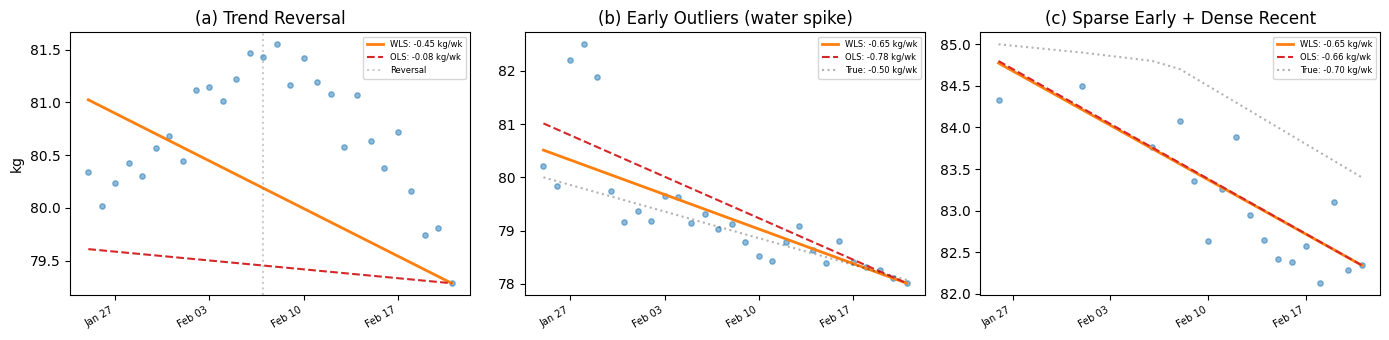

In [72]:
np.random.seed(7)


def ols_slope(weights, ref_date):
    """Naive OLS for comparison (no decay weighting)."""
    cutoff = ref_date - timedelta(days=REGRESSION_WINDOW_DAYS)
    pts = sorted(
        ((d - ref_date).days, v)
        for d, v in weights.items()
        if d > cutoff and d <= ref_date
    )
    if len(pts) < 2:
        return None
    ts = np.array([t for t, _ in pts], dtype=float)
    ys = np.array([v for _, v in pts], dtype=float)
    mean_t, mean_y = ts.mean(), ys.mean()
    num = ((ts - mean_t) * (ys - mean_y)).sum()
    den = ((ts - mean_t) ** 2).sum()
    return float(num / den) if den != 0 else None


def fit_line_from_slope(weights, slope, ref_date, dates):
    """Build fit line from slope anchored at ref_date."""
    anchor = weights.get(ref_date, list(weights.values())[-1])
    return [anchor + slope * (d - ref_date).days for d in dates]


fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=7)

# --- (a) Trend reversal: gaining 2 weeks → losing 2 weeks ---
w_a = {}
for d in range(28):
    dt = REF - timedelta(days=27 - d)
    if d < 14:
        true_w = 80.0 + (0.8 / 7) * d  # gaining ~0.8 kg/wk
    else:
        true_w = 80.0 + (0.8 / 7) * 14 - (1.0 / 7) * (d - 14)  # losing ~1.0 kg/wk
    w_a[dt] = true_w + np.random.normal(0, 0.2)
dates_a = sorted(w_a)
wls_s = wls_slope(w_a, ref_date=REF)
ols_s = ols_slope(w_a, REF)
ax = axes[0]
ax.scatter(dates_a, [w_a[d] for d in dates_a], s=15, alpha=0.5, color="C0")
ax.plot(
    dates_a,
    fit_line_from_slope(w_a, wls_s, REF, dates_a),
    "C1-",
    lw=2,
    label=f"WLS: {wls_s * 7:+.2f} kg/wk",
)
ax.plot(
    dates_a,
    fit_line_from_slope(w_a, ols_s, REF, dates_a),
    "C3--",
    lw=1.5,
    label=f"OLS: {ols_s * 7:+.2f} kg/wk",
)
ax.axvline(REF - timedelta(days=14), color="gray", ls=":", alpha=0.4, label="Reversal")
ax.set(title="(a) Trend Reversal", ylabel="kg")
ax.legend(fontsize=6)

# --- (b) Early outliers: 3 spike weigh-ins in week 1 (water retention) ---
w_b = {}
for d in range(28):
    dt = REF - timedelta(days=27 - d)
    true_w = 80.0 + (-0.5 / 7) * d  # steady loss ~0.5 kg/wk
    w_b[dt] = true_w + np.random.normal(0, 0.2)
# Spike 3 early days (e.g., water retention after travel)
for spike_d in [2, 3, 4]:
    dt = REF - timedelta(days=27 - spike_d)
    w_b[dt] += 2.5  # +2.5 kg water
dates_b = sorted(w_b)
wls_s = wls_slope(w_b, ref_date=REF)
ols_s = ols_slope(w_b, REF)
ax = axes[1]
ax.scatter(dates_b, [w_b[d] for d in dates_b], s=15, alpha=0.5, color="C0")
ax.plot(
    dates_b,
    fit_line_from_slope(w_b, wls_s, REF, dates_b),
    "C1-",
    lw=2,
    label=f"WLS: {wls_s * 7:+.2f} kg/wk",
)
ax.plot(
    dates_b,
    fit_line_from_slope(w_b, ols_s, REF, dates_b),
    "C3--",
    lw=1.5,
    label=f"OLS: {ols_s * 7:+.2f} kg/wk",
)
true_line = [80.0 + (-0.5 / 7) * i for i in range(28)]
ax.plot(dates_b, true_line, "k:", alpha=0.3, label="True: -0.50 kg/wk")
ax.set(title="(b) Early Outliers (water spike)")
ax.legend(fontsize=6)

# --- (c) Sparse start + dense recent: 3 pts in first 2 weeks, daily in last 2 ---
w_c = {}
# Only 3 scattered points in first 14 days
for d in [1, 7, 12]:
    dt = REF - timedelta(days=27 - d)
    true_w = 85.0 + (-0.7 / 7) * d
    w_c[dt] = true_w + np.random.normal(0, 0.4)
# Daily in last 14 days
for d in range(14, 28):
    dt = REF - timedelta(days=27 - d)
    true_w = 85.0 + (-0.7 / 7) * d
    w_c[dt] = true_w + np.random.normal(0, 0.4)
dates_c = sorted(w_c)
wls_s = wls_slope(w_c, ref_date=REF)
ols_s = ols_slope(w_c, REF)
ax = axes[2]
ax.scatter(dates_c, [w_c[d] for d in dates_c], s=15, alpha=0.5, color="C0")
ax.plot(
    dates_c,
    fit_line_from_slope(w_c, wls_s, REF, dates_c),
    "C1-",
    lw=2,
    label=f"WLS: {wls_s * 7:+.2f} kg/wk",
)
ax.plot(
    dates_c,
    fit_line_from_slope(w_c, ols_s, REF, dates_c),
    "C3--",
    lw=1.5,
    label=f"OLS: {ols_s * 7:+.2f} kg/wk",
)
true_line = [85.0 + (-0.7 / 7) * i for i in range(len(dates_c))]
ax.plot(dates_c, true_line, "k:", alpha=0.3, label="True: -0.70 kg/wk")
ax.set(title="(c) Sparse Early + Dense Recent")
ax.legend(fontsize=6)

plt.tight_layout()
plt.show()

## 3. Forbes ρ — How does body fat % change energy density?

ρ determines how many kcal each kg of weight change represents. Higher BF% → more energy per kg (more fat lost).

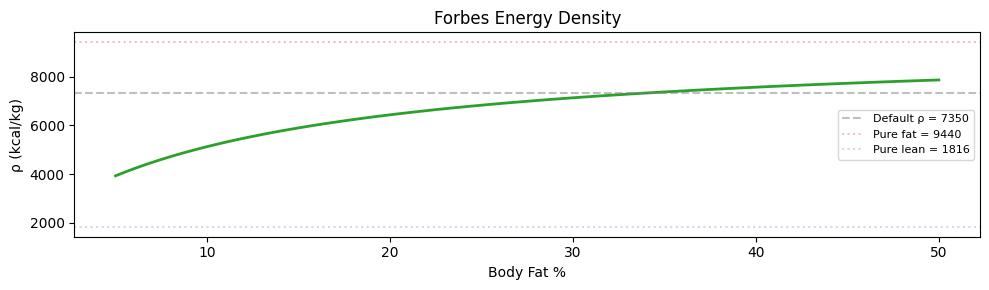

In [73]:
bf_range = np.linspace(0.05, 0.50, 100)
weight = 80.0
rhos = [forbes_rho(bf, weight) for bf in bf_range]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(bf_range * 100, rhos, "C2-", lw=2)
ax.axhline(
    DEFAULT_RHO,
    color="gray",
    ls="--",
    alpha=0.5,
    label=f"Default ρ = {DEFAULT_RHO:.0f}",
)
ax.axhline(
    FAT_TISSUE_ENERGY,
    color="C3",
    ls=":",
    alpha=0.3,
    label=f"Pure fat = {FAT_TISSUE_ENERGY:.0f}",
)
ax.axhline(
    LEAN_TISSUE_ENERGY,
    color="C4",
    ls=":",
    alpha=0.3,
    label=f"Pure lean = {LEAN_TISSUE_ENERGY:.0f}",
)
ax.set(xlabel="Body Fat %", ylabel="ρ (kcal/kg)", title="Forbes Energy Density")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Confidence — Where does the 0→1 ramp happen?

Confidence = density × span. This is the blending weight between measured data and fallback.
Shows weight confidence (min 7 pts) and calorie confidence (min 14 pts).

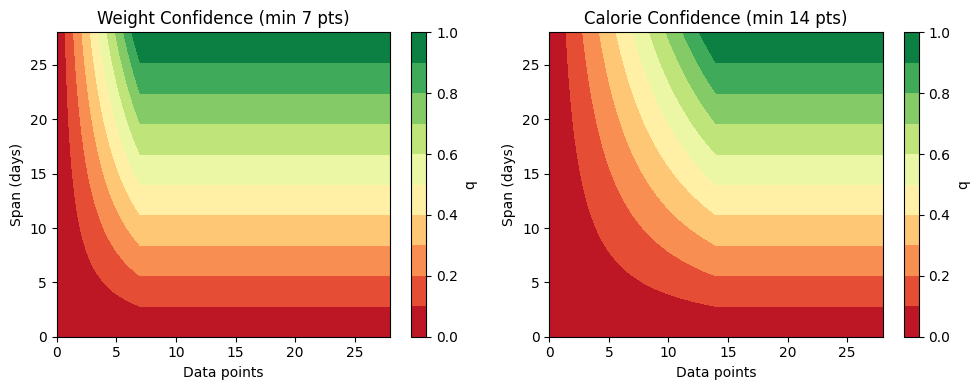

In [74]:
n_range = np.arange(0, 29)
span_range = np.arange(0, 29)
N, S = np.meshgrid(n_range, span_range)

q_w = np.vectorize(lambda n, s: confidence(int(n), int(s), MIN_WEIGHT_DATA_POINTS))(
    N, S
)
q_c = np.vectorize(lambda n, s: confidence(int(n), int(s), MIN_CALORIE_DATA_POINTS))(
    N, S
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, title, min_pts in [
    (ax1, q_w, "Weight", MIN_WEIGHT_DATA_POINTS),
    (ax2, q_c, "Calorie", MIN_CALORIE_DATA_POINTS),
]:
    im = ax.contourf(N, S, data, levels=10, cmap="RdYlGn")
    ax.set(
        xlabel="Data points",
        ylabel="Span (days)",
        title=f"{title} Confidence (min {min_pts} pts)",
    )
    fig.colorbar(im, ax=ax, label="q")
plt.tight_layout()
plt.show()

## 5. Maintenance Convergence — How many days until the estimate stabilizes?

Simulates a new user logging daily (true TDEE = 2200, eating 1800, losing ~0.5 kg/wk).
Slides the reference date forward day by day to watch maintenance converge.

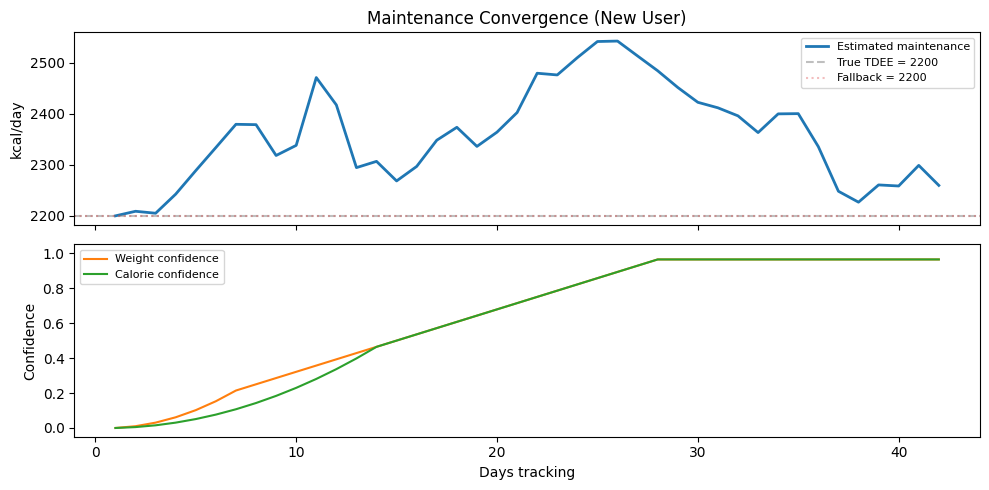

In [75]:
true_tdee = 2200
daily_intake = 1800
true_slope = -0.5

np.random.seed(0)
all_weights = {}
all_calories = {}
for d in range(42):
    dt = REF - timedelta(days=41 - d)
    all_weights[dt] = 80.0 + (true_slope / 7) * d + np.random.normal(0, 0.3)
    all_calories[dt] = daily_intake + np.random.normal(0, 100)

days = list(range(1, 43))
maint = []
w_conf = []
c_conf = []
for d in days:
    ref_d = REF - timedelta(days=42 - d)
    w_sub = {k: v for k, v in all_weights.items() if k <= ref_d}
    c_sub = {k: v for k, v in all_calories.items() if k <= ref_d}
    r = compute_maintenance(w_sub, c_sub, ref_date=ref_d)
    maint.append(r.maintenance)
    w_conf.append(r.weight_confidence)
    c_conf.append(r.calorie_confidence)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax1.plot(days, maint, "C0-", lw=2, label="Estimated maintenance")
ax1.axhline(
    true_tdee, color="gray", ls="--", alpha=0.5, label=f"True TDEE = {true_tdee}"
)
ax1.axhline(
    BASELINE_MAINTENANCE,
    color="C3",
    ls=":",
    alpha=0.3,
    label=f"Fallback = {BASELINE_MAINTENANCE:.0f}",
)
ax1.set(ylabel="kcal/day", title="Maintenance Convergence (New User)")
ax1.legend(fontsize=8)

ax2.plot(days, w_conf, "C1-", label="Weight confidence")
ax2.plot(days, c_conf, "C2-", label="Calorie confidence")
ax2.set(xlabel="Days tracking", ylabel="Confidence", ylim=(-0.05, 1.05))
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Weekly Budget — How does credit redistribute over a week?

Maintenance = 2200, goal = -300 deficit. User eats variably across the week.
Shows daily budget adjusting via credit to keep the weekly total on track.

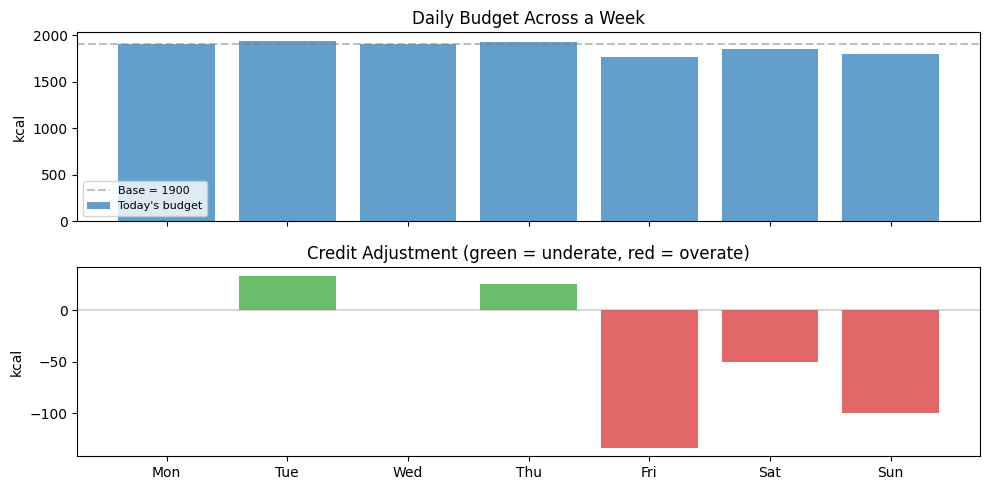

In [76]:
maint_est = 2200.0
goal = -300.0
base = maint_est + goal  # 1900

# Variable daily intake across a week
daily_eats = [1700, 2100, 1800, 2400, 1600, 1900, 0]  # Sun not yet eaten
labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

budgets = []
credits = []
for day_idx in range(7):
    logged = {}
    for i in range(day_idx):
        logged[REF - timedelta(days=6 - i)] = daily_eats[i]
    days_left = 7 - day_idx
    b = compute_budget(maint_est, goal, logged, days_left)
    budgets.append(b.budget)
    credits.append(b.daily_adjustment)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# Budget per day
ax1.bar(labels, budgets, color="C0", alpha=0.7, label="Today's budget")
ax1.axhline(base, color="gray", ls="--", alpha=0.5, label=f"Base = {base:.0f}")
ax1.set(ylabel="kcal", title="Daily Budget Across a Week")
ax1.legend(fontsize=8)

# Credit adjustment
colors = ["C2" if c >= 0 else "C3" for c in credits]
ax2.bar(labels, credits, color=colors, alpha=0.7)
ax2.axhline(0, color="gray", ls="-", alpha=0.3)
ax2.set(ylabel="kcal", title="Credit Adjustment (green = underate, red = overate)")
plt.tight_layout()
plt.show()